## Name: Tanmoy Kumar Das
## email: tnmy468@gmail.com

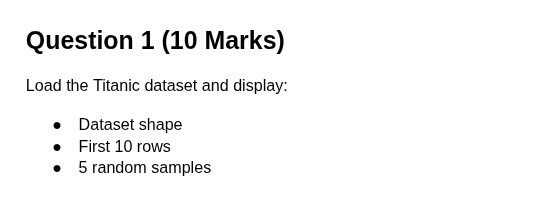

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

df = pd.read_csv('/content/titanic_data_updated.csv')

# dataset shape

print(df.shape)
print(f"Dtaset have {df.shape[1]} potential feature")
print(f"dataset have {df.shape[0]} sample.")

(891, 12)
Dtaset have 12 potential feature
dataset have 891 sample.


In [ ]:
# first 10

df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,no,third,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,no,first,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,no,third,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,yes,third,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,yes,second,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [ ]:
# first 5 sample

df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
389,390,yes,second,"Lehmann, Miss. Bertha",female,17.0,0,0,SC 1748,12.0000,NaN,C
312,313,no,second,"Lahtinen, Mrs. William (Anna Sylfven)",female,26.0,1,1,250651,26.0000,NaN,S
757,758,no,second,"Bailey, Mr. Percy Andrew",male,18.0,0,0,29108,11.5000,NaN,S
364,365,no,third,"O'Brien, Mr. Thomas",male,NaN,1,0,370365,15.5000,NaN,Q
258,259,yes,first,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C


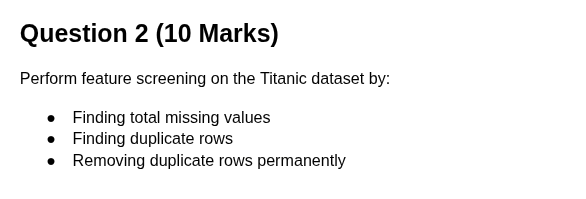

In [ ]:
# total missing values
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
# cheking duplicate

df.duplicated().sum()

np.int64(0)

In [ ]:
# removing duplicate

df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

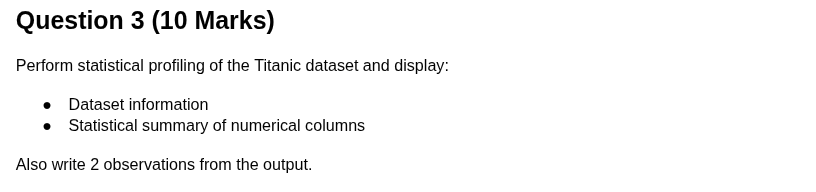

In [ ]:
# datset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    object 
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(3), object(7)
memory usage: 83.7+ KB


In [ ]:
# dataset numerical observation

df.describe()

,PassengerId,Age,SibSp,Parch,Fare
count,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,29.699118,0.523008,0.381594,32.204208
std,257.353842,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,38.000000,1.000000,0.000000,31.000000
max,891.000000,80.000000,8.000000,6.000000,512.329200


# Observatons
### 1. eikahne sob boyoshi manush ache mane 0.4 theke 80 bosor obdi..

### 2. max fare 512 hoileo mean matro 32 to eikhane max fare e lok jon khubie e kom prai lok kom takay fare korteche

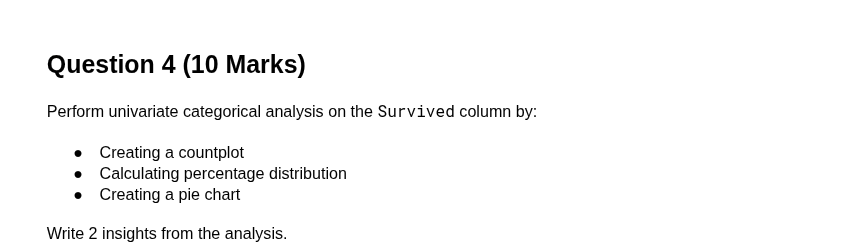

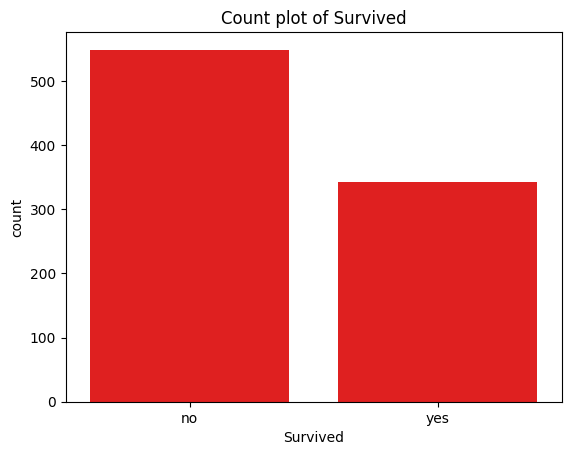

In [ ]:
# drawing count plot

plt.title("Count plot of Survived")
sns.countplot(data=df, x = 'Survived', color='red')
plt.show()

In [ ]:
# percentage of survival

count = df.Survived.value_counts()
(count / len(df)) * 100

,count
Survived,
no,61.616162
yes,38.383838


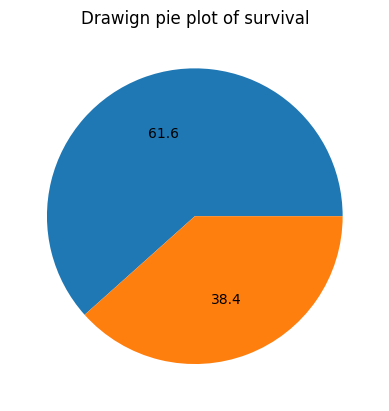

In [ ]:
# drawing pie plot

plt.title("Drawign pie plot of survival")
plt.pie(count, autopct='%1.1f')
plt.show()

# Insights

### 1. 100 jon e prai 38 survive korche
### 2. survival rate kom eikhane survive nah korar possiblities beshi

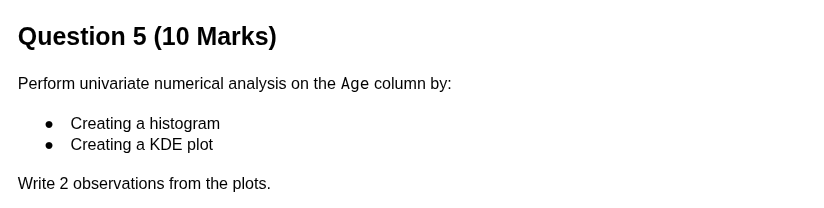

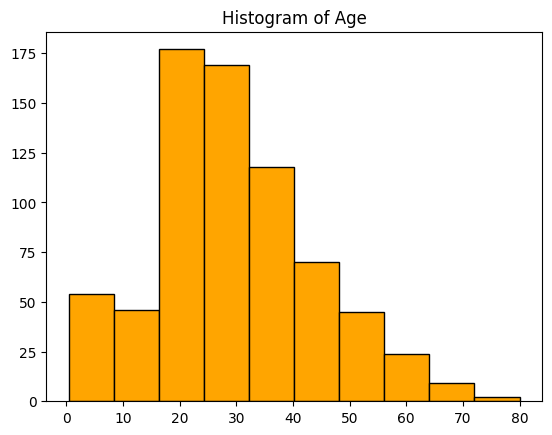

In [ ]:
# histogram of Age

plt.title("Histogram of Age")
plt.hist(df['Age'], edgecolor='black', color='orange')
plt.show()

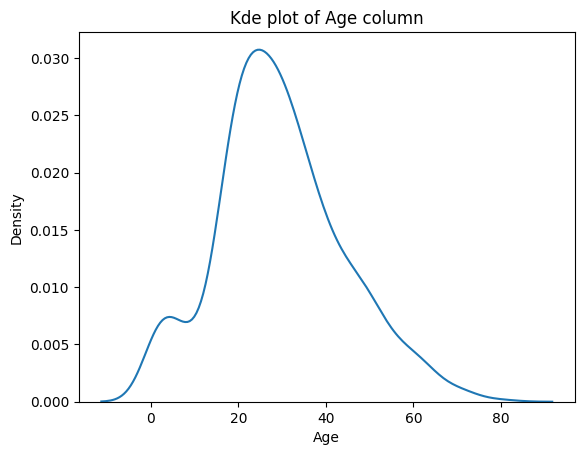

In [ ]:
# Kdeplot of Age

plt.title("Kde plot of Age column")
sns.kdeplot(df['Age'])
plt.show()

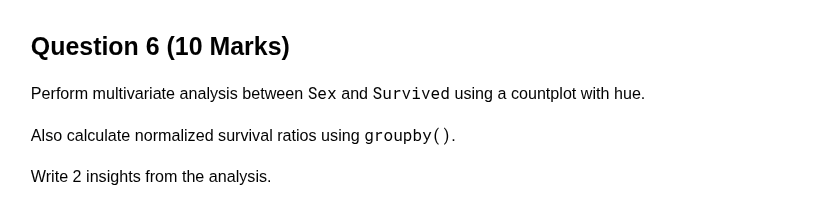

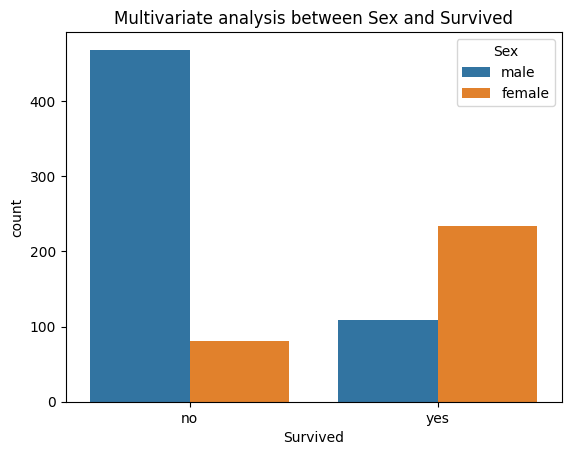

In [ ]:
plt.title("Multivariate analysis between Sex and Survived")
sns.countplot(data=df, x = 'Survived', hue='Sex')
plt.show()

In [ ]:
# Normalized survival ratio
df.groupby('Sex')['Survived'].value_counts(normalize=True)

Sex     Survived
female  yes         0.742038
        no          0.257962
male    no          0.811092
        yes         0.188908
Name: proportion, dtype: float64

# Insights

### 1. Female der survival rate beshi
### 2. Male er survival rate female er unsurvival rate er thekeo kom

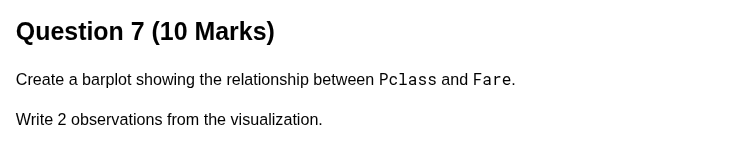

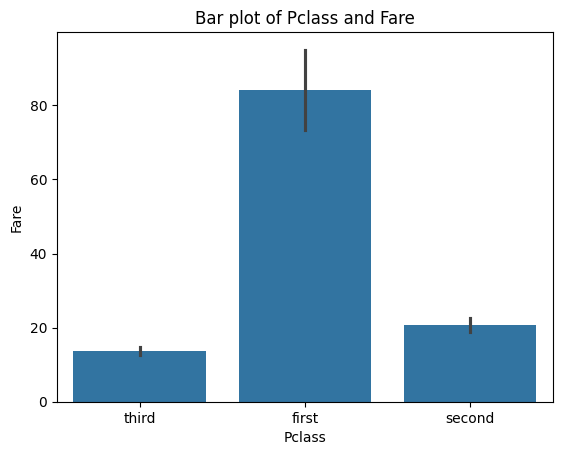

In [ ]:
# drawing bar plot

plt.title("Bar plot of Pclass and Fare")
sns.barplot(x="Pclass", y="Fare", data=df)
plt.show()

# Insights

### 1. First class er fare second and third class er theke onek beshi

### 2. Second ar Third class er moddhe fare er dif khub beshi nah

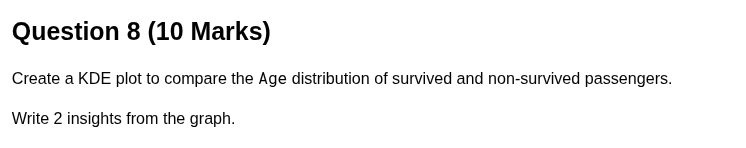

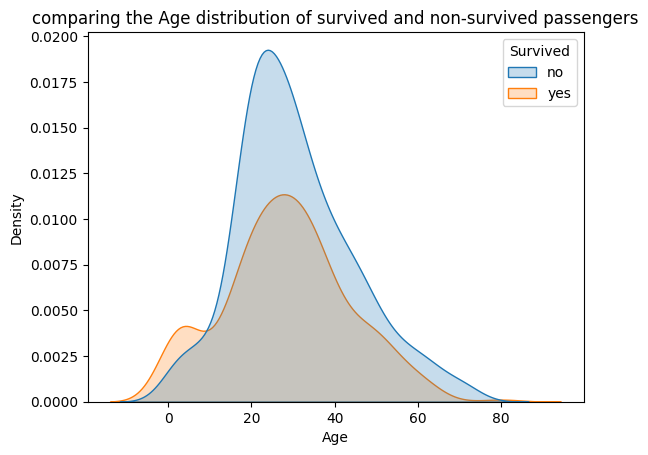

In [ ]:
# darwing kde plot

plt.title("comparing the Age distribution of survived and non-survived passengers")
sns.kdeplot(data=df, x="Age", hue="Survived", fill=True)
plt.show()



# Insights

### 1. Baccader survival rate onek beshi
### 2. 30 bosor er por boyosh barar sathe sathe survival rate komche

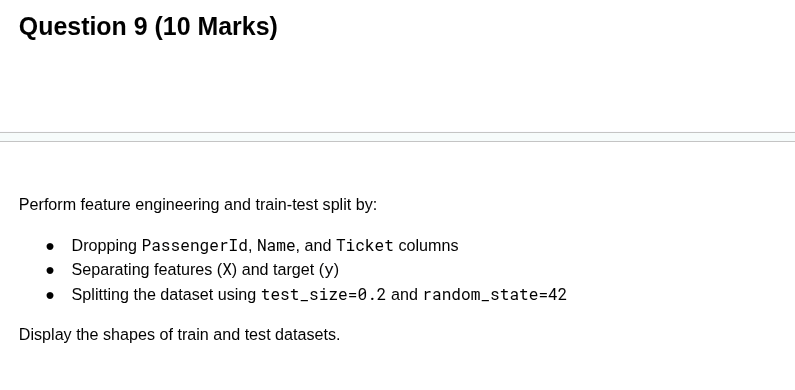

In [ ]:
# spliting traina and test data
x = df.drop(columns=['PassengerId', 'Ticket'])
y = df['Survived']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
# showing test datset

x_test

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
709,yes,third,"Moubarek, Master. Halim Gonios (""William George"")",male,NaN,1,1,15.2458,NaN,C
439,no,second,"Kvillner, Mr. Johan Henrik Johannesson",male,31.0,0,0,10.5000,NaN,S
840,no,third,"Alhomaki, Mr. Ilmari Rudolf",male,20.0,0,0,7.9250,NaN,S
720,yes,second,"Harper, Miss. Annie Jessie ""Nina""",female,6.0,0,1,33.0000,NaN,S
39,yes,third,"Nicola-Yarred, Miss. Jamila",female,14.0,1,0,11.2417,NaN,C
...,...,...,...,...,...,...,...,...,...,...
433,no,third,"Kallio, Mr. Nikolai Erland",male,17.0,0,0,7.1250,NaN,S
773,no,third,"Elias, Mr. Dibo",male,NaN,0,0,7.2250,NaN,C
25,yes,third,"Asplund, Mrs. Carl Oscar (Selma Augusta Emilia...",female,38.0,1,5,31.3875,NaN,S
84,yes,second,"Ilett, Miss. Bertha",female,17.0,0,0,10.5000,NaN,S


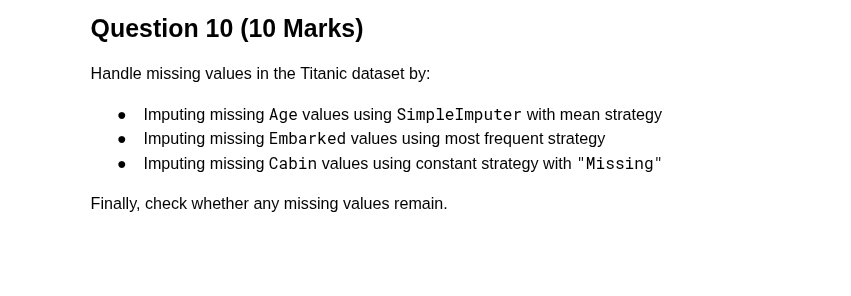

In [ ]:
# Handling null value

age_impute = SimpleImputer(missing_values=np.nan, strategy='mean')
emb_impute = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
cab_impute = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='Missing')


df['Age'] = age_impute.fit_transform(df[['Age']]).ravel()
df['Embarked'] = emb_impute.fit_transform(df[['Embarked']]).ravel()
df['Cabin'] = cab_impute.fit_transform(df[['Cabin']]).ravel()



In [ ]:
# Checking null

df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0
